In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df = pd.read_csv(
    r'/Users/phamhoanghai/Ureca/dataset/output_data.csv',
    dtype={
        'WhiteElo': 'string',
        'BlackElo': 'string',
        'WhiteTitle': 'string',
    },
    na_values=['?'],
    low_memory=False,
)
df = df[['GameID', 'Event', 'White', 'Black', 'WhiteEloNumeric', 'BlackEloNumeric', 'ECO', 'Opening', 'EloDiff', 'AvgElo', 'Result', 'NumericResult']].dropna()
print(df.info())

<class 'pandas.DataFrame'>
Index: 1111082 entries, 0 to 1111301
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   GameID           1111082 non-null  int64  
 1   Event            1111082 non-null  str    
 2   White            1111082 non-null  str    
 3   Black            1111082 non-null  str    
 4   WhiteEloNumeric  1111082 non-null  float64
 5   BlackEloNumeric  1111082 non-null  float64
 6   ECO              1111082 non-null  str    
 7   Opening          1111082 non-null  str    
 8   EloDiff          1111082 non-null  float64
 9   AvgElo           1111082 non-null  float64
 10  Result           1111082 non-null  str    
 11  NumericResult    1111082 non-null  float64
dtypes: float64(5), int64(1), str(6)
memory usage: 110.2 MB
None


In [90]:
df.head()

,GameID,Event,White,Black,WhiteEloNumeric,BlackEloNumeric,ECO,Opening,EloDiff,AvgElo,Result,NumericResult
0,1,Rated Bullet game,sisy,lpaulmp,1645.0,1449.0,D31,Queen's Gambit Declined: Queen's Knight Variation,196.0,1547.0,1-0,1.0
1,2,Rated Blitz game,capablanca1950,ftri67,1603.0,1672.0,C00,French Defense,-69.0,1637.5,0-1,0.0
2,3,Rated Bullet game,daamien,mike81,1166.0,1280.0,D00,Queen's Pawn Game: Steinitz Countergambit,-114.0,1223.0,1-0,1.0
3,4,Rated Blitz game,yaavarmo,JACKELCALVO,1494.0,1449.0,C00,French Defense: Normal Variation,45.0,1471.5,1-0,1.0
4,5,Rated Bullet game,albinofrenchy,galita,1256.0,1285.0,D53,Queen's Gambit Declined: 4.Bg5 Be7,-29.0,1270.5,1-0,1.0


In [91]:
eco_family_map = {
    "A": "Flank Openings",
    "B": "Semi-Open Defenses",
    "C": "Open Games and Semi-Open",
    "D": "Closed and Semi-Closed",
    "E": "Indian Defenses",
}
df["OpeningFamily"] = df["ECO"].str[0].map(eco_family_map).fillna("Unknown")

print(df[["ECO", "OpeningFamily", "Opening"]].head())

   ECO             OpeningFamily  \
0  D31    Closed and Semi-Closed   
1  C00  Open Games and Semi-Open   
2  D00    Closed and Semi-Closed   
3  C00  Open Games and Semi-Open   
4  D53    Closed and Semi-Closed   

                                             Opening  
0  Queen's Gambit Declined: Queen's Knight Variation  
1                                     French Defense  
2          Queen's Pawn Game: Steinitz Countergambit  
3                   French Defense: Normal Variation  
4                 Queen's Gambit Declined: 4.Bg5 Be7  


In [95]:
output_path = r"/Users/phamhoanghai/Ureca/dataset/final_data"
df.to_csv(output_path, index=False)
print(f"Matrix successfully saved to: {output_path}")

Matrix successfully saved to: /Users/phamhoanghai/Ureca/dataset/final_data


In [96]:
from pathlib import Path

split_output_dir = Path(r"/Users/phamhoanghai/Ureca/dataset/final_data_by_event_group")
split_output_dir.mkdir(parents=True, exist_ok=True)

def normalize_event_group(event_value):
    event_text = str(event_value).strip().lower()
    if 'bullet' in event_text:
        return 'rated_bullet'
    if 'blitz' in event_text:
        return 'rated_blitz'
    if 'classical' in event_text:
        return 'rated_classical'
    if 'correspondence' in event_text:
        return 'rated_correspondence'
    return 'other_event'

df['EventGroup'] = df['Event'].apply(normalize_event_group)

for event_group, event_df in df.groupby('EventGroup'):
    event_df.to_csv(split_output_dir / f'{event_group}.csv', index=False)

print(f"Saved {df['EventGroup'].nunique()} grouped event files to: {split_output_dir}")
print(df['EventGroup'].value_counts())


Saved 4 grouped event files to: /Users/phamhoanghai/Ureca/dataset/final_data_by_event_group
EventGroup
rated_blitz             470351
rated_classical         326609
rated_bullet            311197
rated_correspondence      2925
Name: count, dtype: int64


In [103]:
from pathlib import Path
import pandas as pd

base_path = Path(r"/Users/phamhoanghai/Ureca/dataset/final_data_by_event_group")
output_path = base_path / "top30_balanced"
output_path.mkdir(parents=True, exist_ok=True)

event_files = {
    "rated_bullet": base_path / "rated_bullet.csv",
    "rated_blitz": base_path / "rated_blitz.csv",
    "rated_classical": base_path / "rated_classical.csv",
    "rated_correspondence": base_path / "rated_correspondence.csv",
}

random_seed = 42

for event_name, file_path in event_files.items():
    if not file_path.exists():
        print(f"Skip {event_name}: file not found -> {file_path}")
        continue

    event_df = pd.read_csv(file_path)
    opening_counts = event_df["Opening"].value_counts()

    if len(opening_counts) < 30:
        print(f"Skip {event_name}: only {len(opening_counts)} openings available")
        continue

    top30 = opening_counts.head(30)
    threshold_count = int(top30.iloc[-1])
    selected_openings = top30.index.tolist()

    filtered_df = event_df[event_df["Opening"].isin(selected_openings)].copy()
    balanced_df = (
        filtered_df.groupby("Opening", group_keys=False)
        .sample(n=threshold_count, random_state=random_seed)
        .reset_index(drop=True)
    )

    save_file = output_path / f"{event_name}_top30_balanced.csv"
    balanced_df.to_csv(save_file, index=False)

    print(f"\n=== {event_name} ===")
    print(f"30th opening count: {threshold_count}")
    print(f"Saved: {save_file}")
    print(f"Rows: {len(balanced_df)}")
    print(f"Expected rows: {30 * threshold_count}")



=== rated_bullet ===
30th opening count: 1661
Saved: /Users/phamhoanghai/Ureca/dataset/final_data_by_event_group/top30_balanced/rated_bullet_top30_balanced.csv
Rows: 49830
Expected rows: 49830

=== rated_blitz ===
30th opening count: 2851
Saved: /Users/phamhoanghai/Ureca/dataset/final_data_by_event_group/top30_balanced/rated_blitz_top30_balanced.csv
Rows: 85530
Expected rows: 85530

=== rated_classical ===
30th opening count: 2154
Saved: /Users/phamhoanghai/Ureca/dataset/final_data_by_event_group/top30_balanced/rated_classical_top30_balanced.csv
Rows: 64620
Expected rows: 64620

=== rated_correspondence ===
30th opening count: 23
Saved: /Users/phamhoanghai/Ureca/dataset/final_data_by_event_group/top30_balanced/rated_correspondence_top30_balanced.csv
Rows: 690
Expected rows: 690


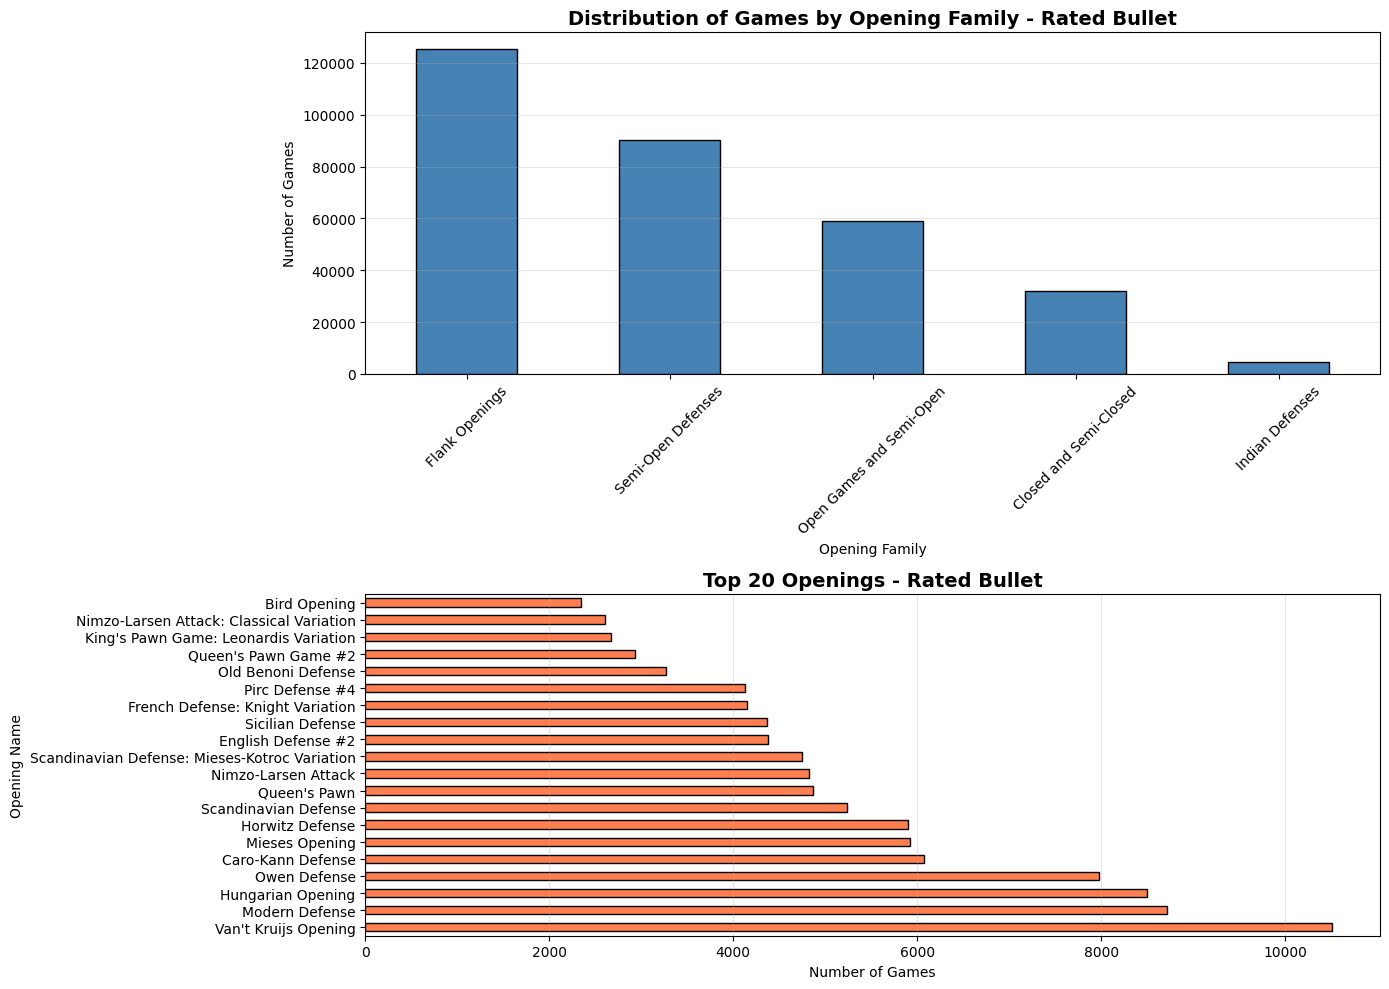


=== Rated Bullet ===

Opening Family Distribution:
OpeningFamily
Flank Openings              125499
Semi-Open Defenses           90186
Open Games and Semi-Open     58884
Closed and Semi-Closed       31924
Indian Defenses               4704
Name: count, dtype: int64

Total families: 5

Top 15 Openings by Name:
Opening
Van't Kruijs Opening                             10505
Modern Defense                                    8711
Hungarian Opening                                 8500
Owen Defense                                      7981
Caro-Kann Defense                                 6073
Mieses Opening                                    5916
Horwitz Defense                                   5895
Scandinavian Defense                              5241
Queen's Pawn                                      4869
Nimzo-Larsen Attack                               4820
Scandinavian Defense: Mieses-Kotroc Variation     4743
English Defense #2                                4377
Sicilian Defense    

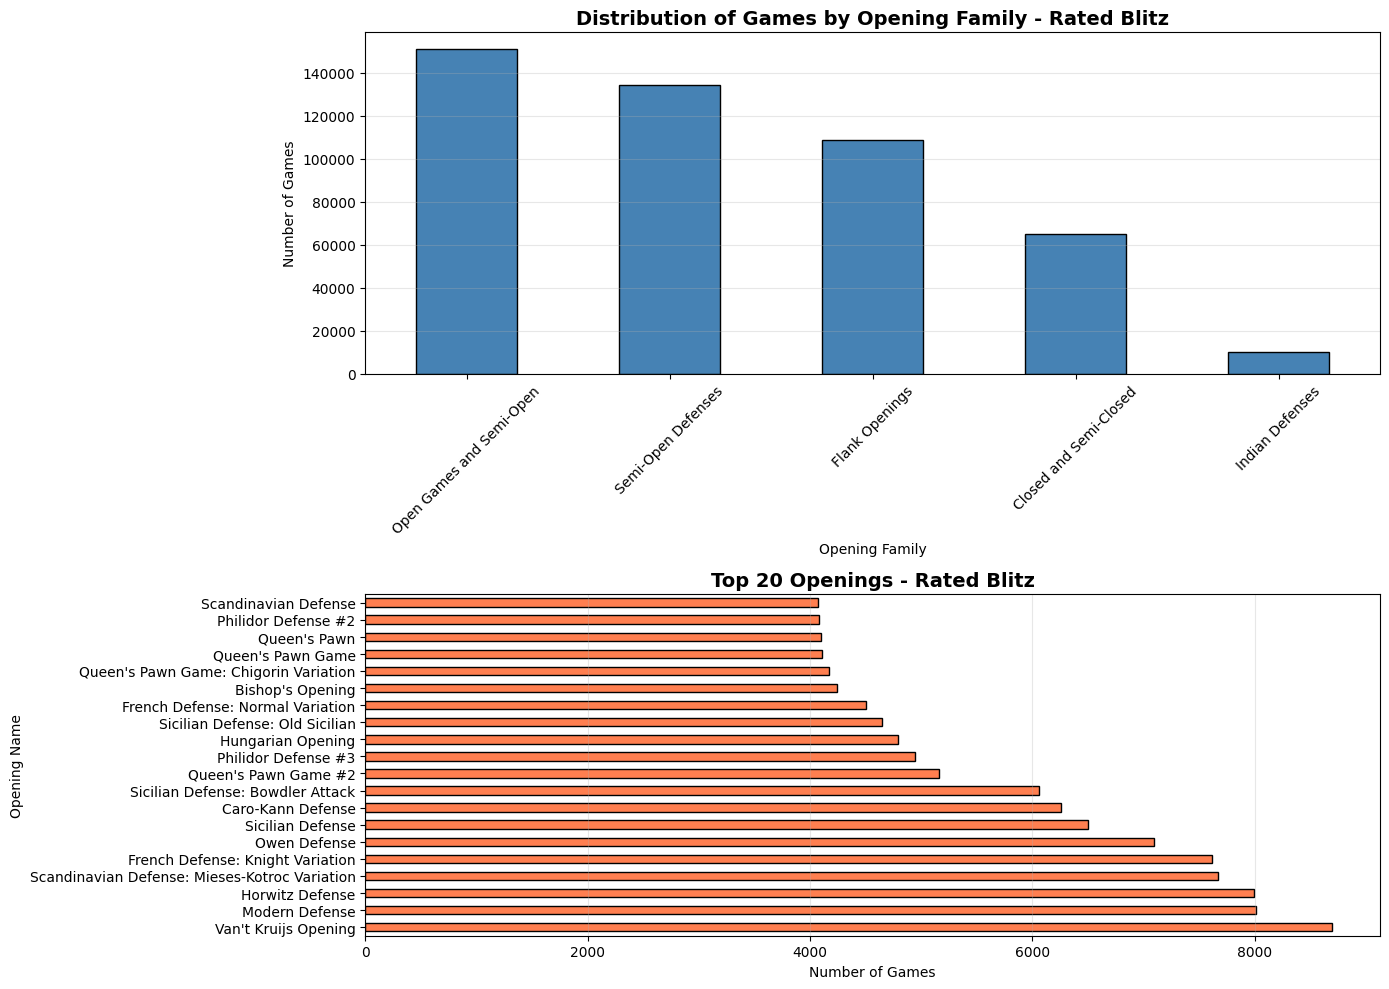


=== Rated Blitz ===

Opening Family Distribution:
OpeningFamily
Open Games and Semi-Open    151347
Semi-Open Defenses          134592
Flank Openings              108995
Closed and Semi-Closed       65187
Indian Defenses              10230
Name: count, dtype: int64

Total families: 5

Top 15 Openings by Name:
Opening
Van't Kruijs Opening                             8694
Modern Defense                                   8017
Horwitz Defense                                  7991
Scandinavian Defense: Mieses-Kotroc Variation    7669
French Defense: Knight Variation                 7615
Owen Defense                                     7094
Sicilian Defense                                 6498
Caro-Kann Defense                                6258
Sicilian Defense: Bowdler Attack                 6061
Queen's Pawn Game #2                             5157
Philidor Defense #3                              4942
Hungarian Opening                                4795
Sicilian Defense: Old Sicilian   

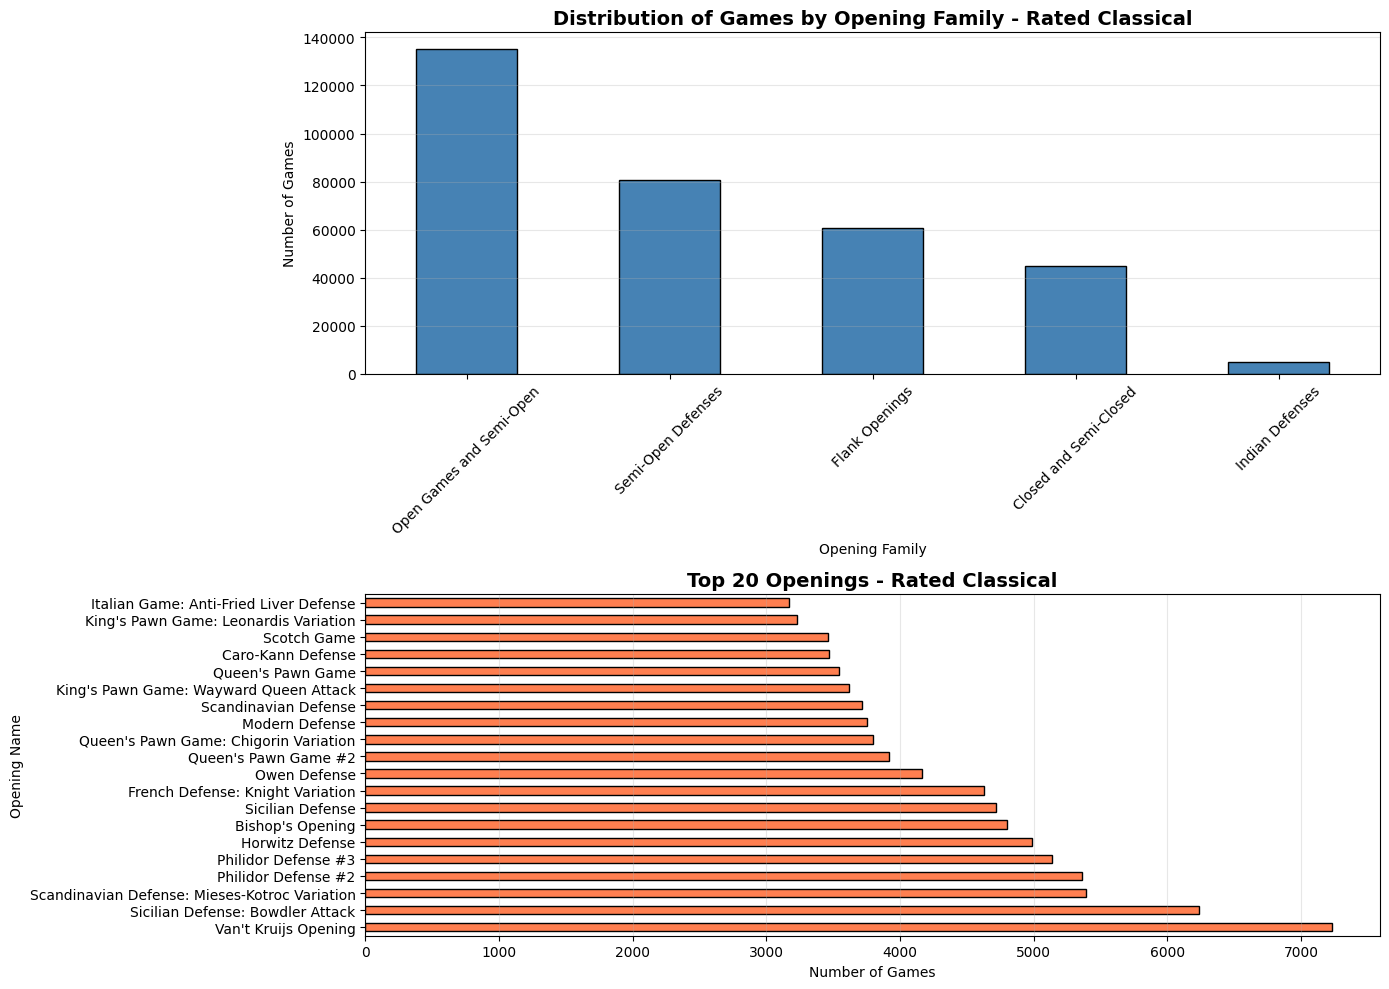


=== Rated Classical ===

Opening Family Distribution:
OpeningFamily
Open Games and Semi-Open    135319
Semi-Open Defenses           80745
Flank Openings               60605
Closed and Semi-Closed       45057
Indian Defenses               4883
Name: count, dtype: int64

Total families: 5

Top 15 Openings by Name:
Opening
Van't Kruijs Opening                             7229
Sicilian Defense: Bowdler Attack                 6235
Scandinavian Defense: Mieses-Kotroc Variation    5388
Philidor Defense #2                              5359
Philidor Defense #3                              5140
Horwitz Defense                                  4987
Bishop's Opening                                 4804
Sicilian Defense                                 4719
French Defense: Knight Variation                 4628
Owen Defense                                     4166
Queen's Pawn Game #2                             3918
Queen's Pawn Game: Chigorin Variation            3801
Modern Defense               

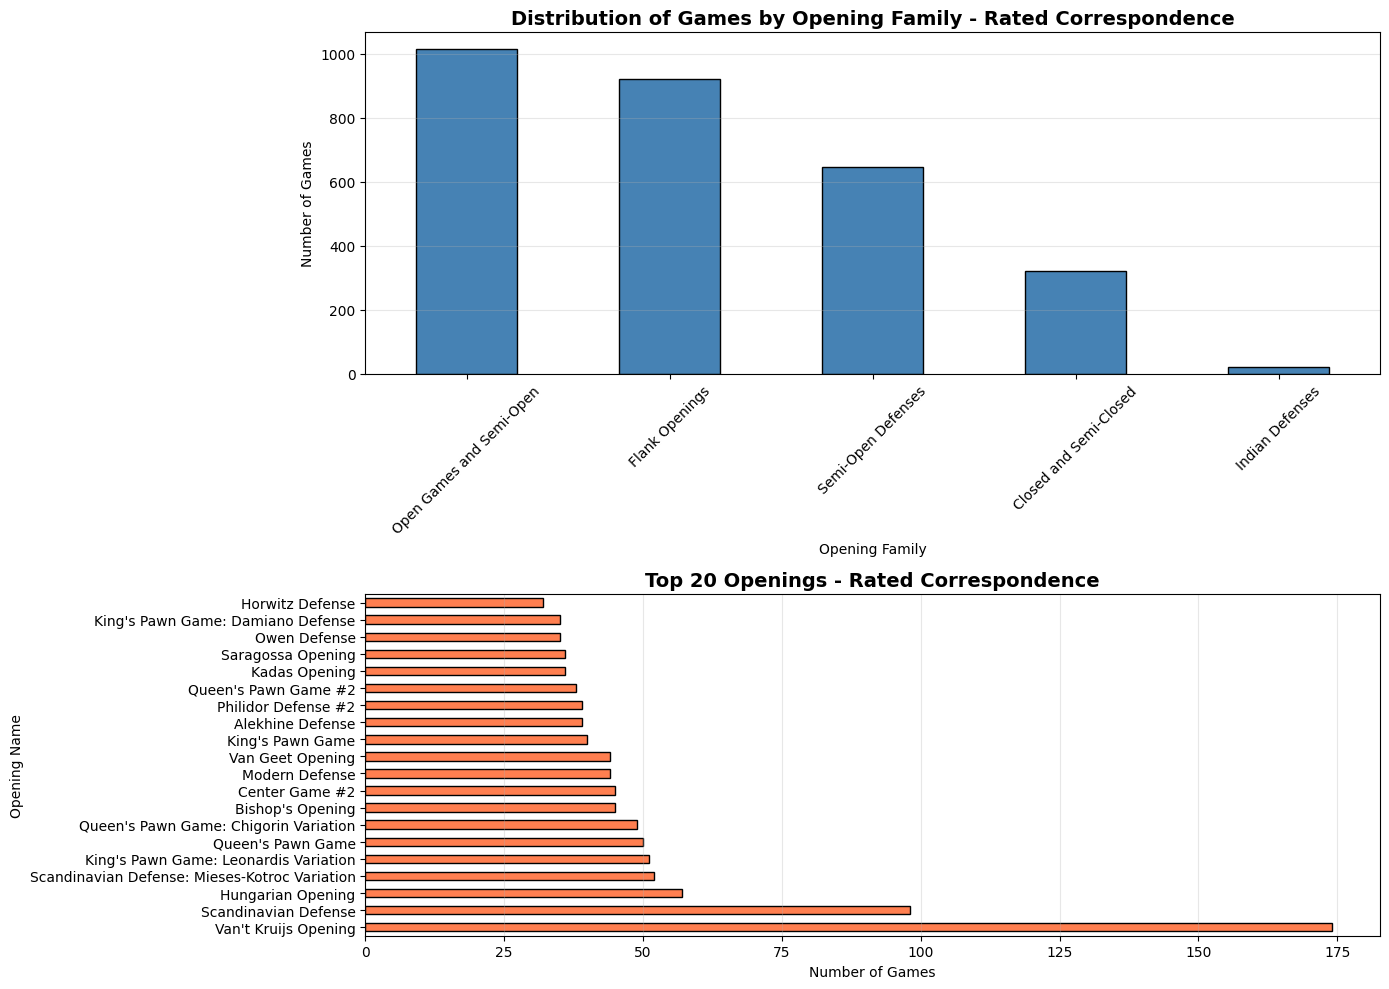


=== Rated Correspondence ===

Opening Family Distribution:
OpeningFamily
Open Games and Semi-Open    1016
Flank Openings               921
Semi-Open Defenses           645
Closed and Semi-Closed       322
Indian Defenses               21
Name: count, dtype: int64

Total families: 5

Top 15 Openings by Name:
Opening
Van't Kruijs Opening                             174
Scandinavian Defense                              98
Hungarian Opening                                 57
Scandinavian Defense: Mieses-Kotroc Variation     52
King's Pawn Game: Leonardis Variation             51
Queen's Pawn Game                                 50
Queen's Pawn Game: Chigorin Variation             49
Bishop's Opening                                  45
Center Game #2                                    45
Modern Defense                                    44
Van Geet Opening                                  44
King's Pawn Game                                  40
Alekhine Defense                              

In [97]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

base_path = Path(r"/Users/phamhoanghai/Ureca/dataset/final_data_by_event_group")

event_files = {
    "Rated Bullet": base_path / "rated_bullet.csv",
    "Rated Blitz": base_path / "rated_blitz.csv",
    "Rated Classical": base_path / "rated_classical.csv",
    "Rated Correspondence": base_path / "rated_correspondence.csv",
}

for event_name, file_path in event_files.items():
    if not file_path.exists():
        print(f"{event_name}: file not found -> {file_path}")
        continue

    df = pd.read_csv(file_path)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Distribution of games by Opening Family
    family_counts = df["OpeningFamily"].value_counts().sort_values(ascending=False)
    family_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
    axes[0].set_title(f"Distribution of Games by Opening Family - {event_name}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Opening Family")
    axes[0].set_ylabel("Number of Games")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].tick_params(axis="x", rotation=45)

    # Plot 2: Top 20 openings
    name_counts = df["Opening"].value_counts().head(20)
    name_counts.plot(kind="barh", ax=axes[1], color="coral", edgecolor="black")
    axes[1].set_title(f"Top 20 Openings - {event_name}", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Number of Games")
    axes[1].set_ylabel("Opening Name")
    axes[1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n=== {event_name} ===")
    print("\nOpening Family Distribution:")
    print(family_counts)
    print(f"\nTotal families: {len(family_counts)}")

    print("\nTop 15 Openings by Name:")
    print(df["Opening"].value_counts().head(15))
    print(f"\nTotal unique openings: {df['Opening'].nunique()}")


Because the dataset for Rated Correspond is too low for each openings, I will only consider by family distribution
